# Машинное обучение
# Задание 1. Ridge-регрессия

Дата выдачи: 07.09.2026

### О задании

Вы научитесь:
 * подготавливать данные для обучения линейных моделей;
 * обучать Ridge-регрессию при помощи модуля scikit-learn;
 * вычислять ошибки на валидационной и тренировочной выборках;
 * проверять модель на переобучение;
 * оценивать качество модели

#### Шаг 1. Скачайте датасет, откройте его и выведите таблицу на экран

In [1]:
import pandas as pd

df = pd.read_csv('apartment_dataset.csv')
print('Размер датасета:', df.shape)
display(df)


Размер датасета: (200, 6)


,apartment id,rooms,total area,floor,complex rating,price
0,1,2,60.8,9,4.2,11.54
1,2,4,102.5,17,4.6,20.22
2,3,3,75.7,17,4.9,15.74
3,4,2,66.0,20,4.7,14.10
4,5,1,39.7,16,3.6,6.71
...,...,...,...,...,...,...
195,196,1,44.9,17,3.6,7.81
196,197,3,91.7,5,3.5,14.14
197,198,3,81.9,5,3.5,12.91
198,199,3,89.3,6,4.7,17.37


#### Шаг2. Разделите выборку на тренировочную валидационную и тестовую:
* в тренировочной: 100 первых квартир;
* в валидационной: 50 следующих квартир; 
* в тестовой: 50 последних квартир.
* в каждой выборке матрица X - это столбцы rooms, total area, floor, complex rating, а y - столбец price. 

Названия: X_train, y_train, X_val, y_val, X_test, y_test. 

In [2]:
feature_cols = ['rooms', 'total area', 'floor', 'complex rating']
target_col = 'price'

X_train = df.loc[:99, feature_cols].copy()
y_train = df.loc[:99, target_col].copy()

X_val = df.loc[100:149, feature_cols].copy()
y_val = df.loc[100:149, target_col].copy()

X_test = df.loc[150:199, feature_cols].copy()
y_test = df.loc[150:199, target_col].copy()

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (100, 4) (100,)
Validation: (50, 4) (50,)
Test: (50, 4) (50,)


#### Шаг 3. Устанавите sklearn чтобы обучать модель Ridge-регрессии

In [3]:
import sys
# !{sys.executable} -m pip install -q scikit-learn matplotlib


#### Шаг 4. Обучите модель линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg с ошибкой, которая вычисляется по формуле SSE.

In [4]:
import numpy as np
from sklearn.linear_model import Ridge

ridge_alpha = 1.0

model = Ridge(alpha=ridge_alpha, solver='sparse_cg', tol=1e-10, max_iter=1000)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
train_sse = np.sum((y_train.to_numpy() - y_train_pred) ** 2)

print('Коэффициенты модели:', model.coef_)
print('Свободный член:', model.intercept_)
print(f'SSE на train: {train_sse:.6f}')


Коэффициенты модели: [0.31896318 0.14950812 0.0410727  2.05016477]
Свободный член: -7.348209494688101
SSE на train: 14.577443


#### Шаг 5. Выведите на экран графики ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок, чтобы отследить их траекторию.

Для этого задания нужно расписать алгоритм обучения вручную, так как функция Ridge в питоне внутри себя эти ошибки не сохраняет.

В самом алгоритме нужно считать и сохранять SSE, MSE, RMSE на каждом шаге итерации для train и для val выборки.

Перед началом алгоритма нужно задать эпсилон - значение ошибки, после которой обучение останавливается, и количество максимальных итераций.

Обучение должно останавливаться тогда, когда выполнен один из двух критериев остановки: либо модуль ошибки меньше эпсилон, либо количество итераций дошло до максимального числа.

* SSE - сумма всех квадратичных отклонений
* MSE - средеее квадратичное отклонение
* RMSE - среднее отклонение предсказания ответа

Подумайте, какие значения для нашего датасета у этих ошибок могут быть допустимыми, чтобы утверждать, что модель обучилась качественно.

После подсчета всех ошибок на всех итерациях нужно вывести на экран три графика:
* график SSE в зависимости от номера итерации: две линии (для train и val)
* график MSE в зависимости от номера итерации: две линии (для train и val)
* график RMSE в зависимости от номера итерации: две линии (для train и val)

Алгоритм остановился после 5 итераций
Финальный train RMSE: 0.3818
Финальный validation RMSE: 0.3977


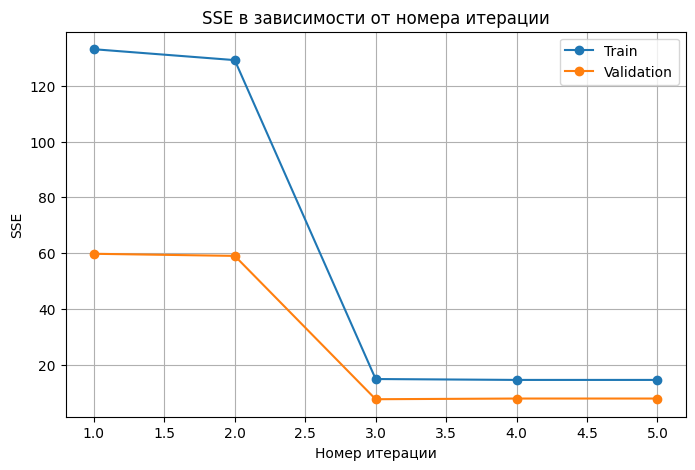

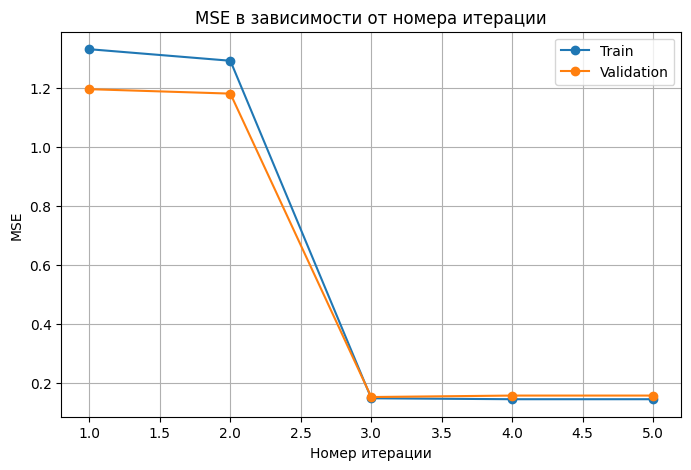

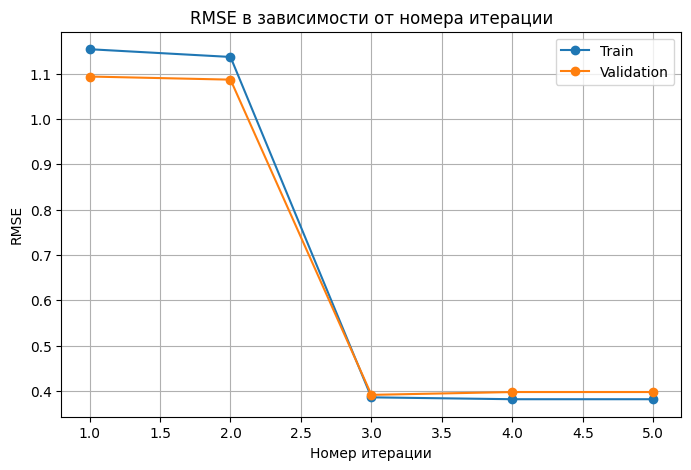

In [5]:
import matplotlib.pyplot as plt

Xtr = X_train.to_numpy(dtype=float)
ytr = y_train.to_numpy(dtype=float)
Xv = X_val.to_numpy(dtype=float)
yv = y_val.to_numpy(dtype=float)

X_mean = Xtr.mean(axis=0)
y_mean = ytr.mean()
X_centered = Xtr - X_mean
y_centered = ytr - y_mean

A = X_centered.T @ X_centered + ridge_alpha * np.eye(X_centered.shape[1])
b = X_centered.T @ y_centered

epsilon = 1e-10
max_iter = 50

w = np.zeros(X_centered.shape[1])
r = b - A @ w
p = r.copy()

iterations = []
train_sse_history, val_sse_history = [], []
train_mse_history, val_mse_history = [], []
train_rmse_history, val_rmse_history = [], []

for k in range(1, max_iter + 1):
    Ap = A @ p
    cg_step = (r @ r) / (p @ Ap)
    w = w + cg_step * p
    r_new = r - cg_step * Ap

    intercept = y_mean - X_mean @ w

    train_pred = Xtr @ w + intercept
    val_pred = Xv @ w + intercept

    train_sse_k = np.sum((ytr - train_pred) ** 2)
    val_sse_k = np.sum((yv - val_pred) ** 2)
    train_mse_k = train_sse_k / len(ytr)
    val_mse_k = val_sse_k / len(yv)
    train_rmse_k = np.sqrt(train_mse_k)
    val_rmse_k = np.sqrt(val_mse_k)

    iterations.append(k)
    train_sse_history.append(train_sse_k)
    val_sse_history.append(val_sse_k)
    train_mse_history.append(train_mse_k)
    val_mse_history.append(val_mse_k)
    train_rmse_history.append(train_rmse_k)
    val_rmse_history.append(val_rmse_k)

    if np.linalg.norm(r_new) < epsilon:
        r = r_new
        break

    beta = (r_new @ r_new) / (r @ r)
    p = r_new + beta * p
    r = r_new

print(f'Алгоритм остановился после {len(iterations)} итераций')
print(f'Финальный train RMSE: {train_rmse_history[-1]:.4f}')
print(f'Финальный validation RMSE: {val_rmse_history[-1]:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_sse_history, marker='o', label='Train')
plt.plot(iterations, val_sse_history, marker='o', label='Validation')
plt.xlabel('Номер итерации')
plt.ylabel('SSE')
plt.title('SSE в зависимости от номера итерации')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_mse_history, marker='o', label='Train')
plt.plot(iterations, val_mse_history, marker='o', label='Validation')
plt.xlabel('Номер итерации')
plt.ylabel('MSE')
plt.title('MSE в зависимости от номера итерации')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_rmse_history, marker='o', label='Train')
plt.plot(iterations, val_rmse_history, marker='o', label='Validation')
plt.xlabel('Номер итерации')
plt.ylabel('RMSE')
plt.title('RMSE в зависимости от номера итерации')
plt.grid(True)
plt.legend()
plt.show()


#### Ответьте на вопрос, какую модель Вы получили: обученную, переобученную или недообученную?

модель получилась без явного переобучения. ошибки на train и val быстро снизились и после схождения остались примерно одинаковыми: RMSE около 0.38 и 0.40.


#### Шаг 6. Применяем модель на тестовой выборке, чтобы предсказать цены квартир.

1. Найдите y_predict

2. Для каждой квартиры из test выведите на экран:
* id квартиры
* её предсказанную цену
* её настоящую цену
* разницу между предсказанной и настоящей ценой (чтобы оценить насколько хорошо Ваша модель предсказывает цены)

3. сохранить получившуюся таблицу

P.S. В итоговой таблице все столбцы должны быть подписаны.

In [6]:
y_predict = model.predict(X_test)

result = pd.DataFrame({
    'apartment id': df.loc[150:199, 'apartment id'].to_numpy(),
    'predicted price': y_predict,
    'real price': y_test.to_numpy(),
    'difference': y_predict - y_test.to_numpy()
})

result.to_csv('apartment_predictions.csv', index=False)

test_sse = np.sum((y_test.to_numpy() - y_predict) ** 2)
test_mse = test_sse / len(y_test)
test_rmse = np.sqrt(test_mse)

print(f'Test SSE: {test_sse:.4f}')
print(f'Test MSE: {test_mse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')
display(result)


Test SSE: 10.1542
Test MSE: 0.2031
Test RMSE: 0.4506


,apartment id,predicted price,real price,difference
0,151,20.854989,21.54,-0.685011
1,152,9.919720,9.73,0.189720
2,153,7.677597,7.74,-0.062403
3,154,10.432702,10.15,0.282702
4,155,17.599486,17.27,0.329486
5,156,8.960634,8.23,0.730634
6,157,8.373601,8.52,-0.146399
7,158,14.716195,14.95,-0.233805
8,159,8.474296,8.16,0.314296
9,160,14.875665,14.95,-0.074335


### Поздравляю! Вы обучили модель и уже сделали первый шаг в машинном обучении! Молодцы!